In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
data = pd.read_excel("students_data.xlsx")

print("📊 عرض أول 5 صفوف من البيانات:")
print(data.head())


📊 عرض أول 5 صفوف من البيانات:
   Student_ID  Exam  Homework  Participation  Practical  Final_Grade
0        1000    89        12              7         23           47
1        1001    70        14              7         30           42
2        1002    89        12              7         23           47
3        1003    61        11              8         28           38
4        1004    56        12              8         23           34


In [ ]:
data['Exam']

TypeError: 'Index' object is not callable

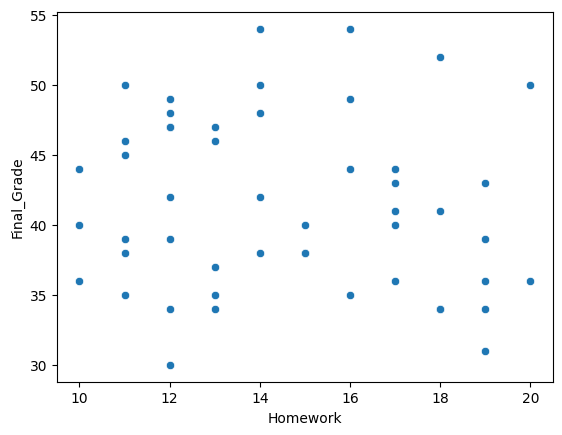

In [8]:
sns.scatterplot(x=data['Homework'],y=data['Final_Grade'])
plt.show()

In [ ]:
print("🔎 معلومات عن البيانات:")
print(data.info())
print("\n📏 إحصائيات عن الأعمدة:")
print(data.describe())


🔎 معلومات عن البيانات:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Student_ID     50 non-null     int64
 1   Exam           50 non-null     int64
 2   Homework       50 non-null     int64
 3   Participation  50 non-null     int64
 4   Practical      50 non-null     int64
 5   Final_Grade    50 non-null     int64
dtypes: int64(6)
memory usage: 2.5 KB
None

📏 إحصائيات عن الأعمدة:
       Student_ID       Exam   Homework  Participation  Practical  Final_Grade
count    50.00000   50.00000  50.000000      50.000000   50.00000    50.000000
mean   1024.50000   73.44000  14.560000       7.420000   24.66000    41.440000
std      14.57738   15.19957   3.024795       1.566095    3.40234     6.178171
min    1000.00000   51.00000  10.000000       5.000000   20.00000    30.000000
25%    1012.25000   60.25000  12.000000       6.000000   21.25000    36.00000

In [ ]:
missing = data.isnull().sum()
print("❌ عدد القيم الفارغة في كل عمود:")
print(missing)

data = data.fillna(data.mean())


❌ عدد القيم الفارغة في كل عمود:
Student_ID       0
Exam             0
Homework         0
Participation    0
Practical        0
Final_Grade      0
dtype: int64


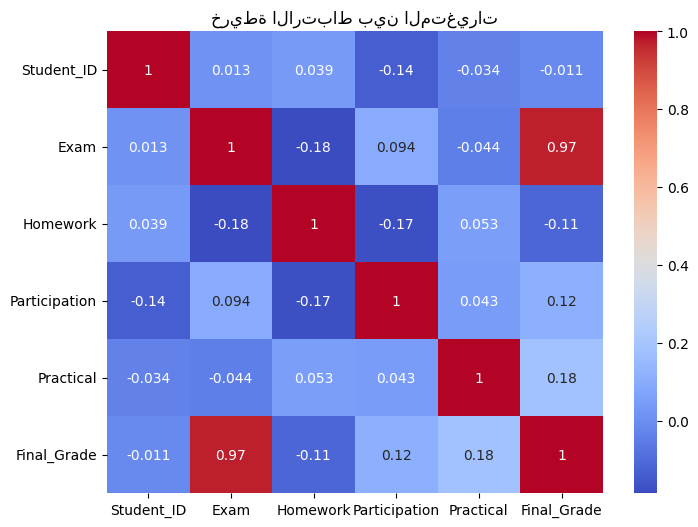

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("خريطة الارتباط بين المتغيرات")
plt.show()


In [ ]:
X = data[["Exam", "Homework", "Participation", "Practical"]] 
y = data["Final_Grade"]  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("✅ تم تقسيم البيانات:")
print(f"حجم التدريب: {X_train.shape}, حجم الاختبار: {X_test.shape}")


✅ تم تقسيم البيانات:
حجم التدريب: (40, 4), حجم الاختبار: (10, 4)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ تم تدريب النموذج بنجاح")


✅ تم تدريب النموذج بنجاح


In [ ]:
y_pred = model.predict(X_test)

print("📊 أول 10 قيم متوقعة مقابل القيم الحقيقية:")
df_compare = pd.DataFrame({"حقيقي": y_test.values[:10], "متوقع": y_pred[:10]})
print(df_compare)


📊 أول 10 قيم متوقعة مقابل القيم الحقيقية:
   حقيقي      متوقع
0     34  33.979115
1     43  42.736303
2     52  52.044701
3     30  30.447928
4     40  40.481167
5     44  44.333426
6     41  41.468979
7     47  46.578026
8     39  39.033491
9     48  48.042042


In [ ]:
print("✅ معاملات الانحدار:", model.coef_)
print("✅ الحد الثابت:", model.intercept_)
print("📉 متوسط الخطأ التربيعي:", mean_squared_error(y_test, y_pred))
print("📈 R² Score:", r2_score(y_test, y_pred))


✅ معاملات الانحدار: [0.40082787 0.12549822 0.10733577 0.40101146]
✅ الحد الثابت: -0.48652332081316985
📉 متوسط الخطأ التربيعي: 0.1016197518844882
📈 R² Score: 0.9973782313755292


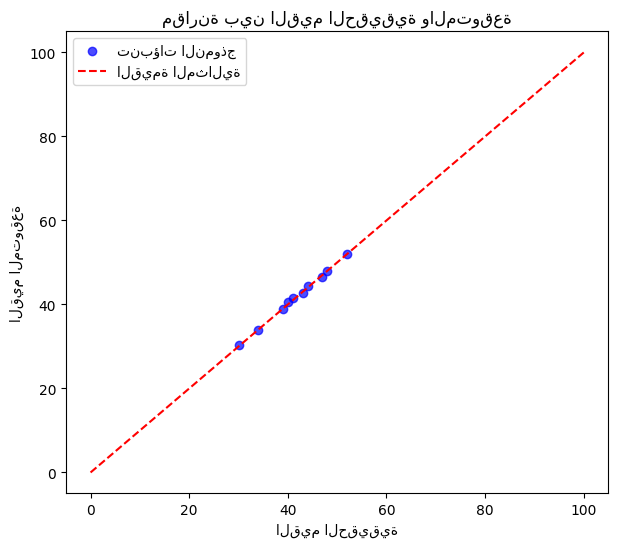

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.7, label="تنبؤات النموذج")
plt.plot([0, 100], [0, 100], color="red", linestyle="--", label="القيمة المثالية")
plt.xlabel("القيم الحقيقية")
plt.ylabel("القيم المتوقعة")
plt.title("مقارنة بين القيم الحقيقية والمتوقعة")
plt.legend()
plt.show()


In [ ]:
new_student = pd.DataFrame({
    "Exam": [85],
    "Homework": [15],
    "Participation": [8],
    "Practical": [25]
})

prediction = model.predict(new_student)
print(f"🎯 التوقع للطالب الجديد = {prediction[0]:.2f}")


🎯 التوقع للطالب الجديد = 46.35
